In [ ]:
pip install pandas matplotlib

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
# importaciones necesarias
from ast import main
from fileinput import filename
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt


def F_INFO_CSV(C_CSV_FOLDER, C_LISTA_ARCHIVOS):
	"""
	Muestra la cantidad de columnas y los encabezados de cada archivo CSV en la carpeta especificada.
	"""
	V_CSV_FILES = [F for F in os.listdir(C_CSV_FOLDER) if F.endswith(C_LISTA_ARCHIVOS)]
	print('Información de columnas y encabezados por archivo:')
	D_ENCABEZADOS_POR_ARCHIVO = {}
	for V_FILENAME in V_CSV_FILES:
		V_FILE_PATH = os.path.join(C_CSV_FOLDER, V_FILENAME)
		with open(V_FILE_PATH, newline='', encoding='utf-8-sig') as V_CSVFILE:
			V_READER = csv.reader(V_CSVFILE)
			V_HEADER = next(V_READER, None)
			if V_HEADER is not None:
				V_NUM_COLUMNAS = len(V_HEADER)
			else:
				V_NUM_COLUMNAS = 0
				V_HEADER = []
		print(f'{V_FILENAME}: {V_NUM_COLUMNAS} columnas')
		print(f'Encabezados: {V_HEADER}')
		D_ENCABEZADOS_POR_ARCHIVO[V_FILENAME] = V_HEADER
	return D_ENCABEZADOS_POR_ARCHIVO

def F_ENCABEZADOS_REPETIDOS(D_ENCABEZADOS_POR_ARCHIVO):
	"""
	Recibe un diccionario {ARCHIVO: [ENCABEZADOS]} y construye otro {ENCABEZADO: [ARCHIVOS]}
	Imprime los encabezados que aparecen en más de un archivo.
	"""
	D_ENCABEZADO_A_ARCHIVOS = {}
	for V_ARCHIVO, L_ENCABEZADOS in D_ENCABEZADOS_POR_ARCHIVO.items():
		for V_ENCABEZADO in L_ENCABEZADOS:
			if V_ENCABEZADO not in D_ENCABEZADO_A_ARCHIVOS:
				D_ENCABEZADO_A_ARCHIVOS[V_ENCABEZADO] = []
			D_ENCABEZADO_A_ARCHIVOS[V_ENCABEZADO].append(V_ARCHIVO)
	print('\nEncabezados repetidos:')
	for V_ENCABEZADO, L_ARCHIVOS in D_ENCABEZADO_A_ARCHIVOS.items():
		if len(L_ARCHIVOS) > 1:
			print(f'{V_ENCABEZADO} = {L_ARCHIVOS}')

def F_COUNT_ROWS(C_CSV_FOLDER, C_LISTA_ARCHIVOS):
	# Listar todos los archivos CSV en la carpeta
	V_CSV_FILES = [f for f in os.listdir(C_CSV_FOLDER) if f.endswith(C_LISTA_ARCHIVOS)]

	print('Conteo de filas por archivo:')
	for V_FILENAME in V_CSV_FILES:
		V_FILE_PATH = os.path.join(C_CSV_FOLDER, V_FILENAME)
		with open(V_FILE_PATH, newline='', encoding='utf-8-sig') as V_CSVFILE:
			reader = csv.reader(V_CSVFILE)
			# Saltar encabezado
			next(reader, None)
			V_ROW_COUNT = sum(1 for row in reader)
		print(f'{V_FILENAME}: {V_ROW_COUNT} filas')


def F_CARGAR_DATAFRAMES(C_CSV_FOLDER, C_LISTA_ARCHIVOS):
	"""
	Carga todos los archivos CSV de la carpeta en un diccionario de DataFrames.
	Retorna {nombre_sin_extension: DataFrame}.
	"""
	V_CSV_FILES = [F for F in os.listdir(C_CSV_FOLDER) if F.endswith(C_LISTA_ARCHIVOS)]
	D_DATAFRAMES = {}
	for V_FILENAME in V_CSV_FILES:
		V_FILE_PATH = os.path.join(C_CSV_FOLDER, V_FILENAME)
		V_NOMBRE = V_FILENAME.replace('.csv', '')
		D_DATAFRAMES[V_NOMBRE] = pd.read_csv(V_FILE_PATH, encoding='utf-8-sig')
	print(f'DataFrames cargados: {list(D_DATAFRAMES.keys())}')
	return D_DATAFRAMES


def F_INFO_DATAFRAMES(D_DATAFRAMES):
	"""
	Ejecuta df.info() y df.describe() para cada DataFrame cargado.
	"""
	for V_NOMBRE, V_DF in D_DATAFRAMES.items():
		print(f'\n{"="*60}')
		print(f'TABLA: {V_NOMBRE}')
		print(f'{"="*60}')
		print('\n--- info() ---')
		V_DF.info()
		print('\n--- describe() ---')
		print(V_DF.describe(include='all'))


def F_CALIDAD_DATOS(D_DATAFRAMES):
	"""
	Analiza valores nulos por columna en cada DataFrame.
	Muestra cantidad y porcentaje de nulos.
	"""
	print('\n--- Calidad de datos: valores nulos ---')
	for V_NOMBRE, V_DF in D_DATAFRAMES.items():
		V_NULOS = V_DF.isnull().sum()
		V_PORCENTAJE_NULOS = (V_NULOS / len(V_DF)) * 100
		D_CALIDAD = pd.DataFrame({'nulos': V_NULOS, 'porcentaje': V_PORCENTAJE_NULOS})
		D_CALIDAD_CON_NULOS = D_CALIDAD[D_CALIDAD['nulos'] > 0]
		print(f'\n{V_NOMBRE}:')
		if D_CALIDAD_CON_NULOS.empty:
			print('  Sin valores nulos.')
		else:
			print(D_CALIDAD_CON_NULOS.to_string())


def F_RELACIONES_TABLAS(D_ENCABEZADOS_POR_ARCHIVO):
	"""
	Muestra relaciones potenciales entre tablas como pares vinculados por una clave compartida.
	"""
	D_ENCABEZADO_A_ARCHIVOS = {}
	for V_ARCHIVO, L_ENCABEZADOS in D_ENCABEZADOS_POR_ARCHIVO.items():
		for V_ENCABEZADO in L_ENCABEZADOS:
			if V_ENCABEZADO not in D_ENCABEZADO_A_ARCHIVOS:
				D_ENCABEZADO_A_ARCHIVOS[V_ENCABEZADO] = []
			D_ENCABEZADO_A_ARCHIVOS[V_ENCABEZADO].append(V_ARCHIVO)

	print('\n--- Relaciones entre tablas (claves compartidas) ---')
	for V_CLAVE, L_TABLAS in D_ENCABEZADO_A_ARCHIVOS.items():
		if len(L_TABLAS) > 1:
			for V_I in range(len(L_TABLAS)):
				for V_J in range(V_I + 1, len(L_TABLAS)):
					print(f'  {L_TABLAS[V_I]} <-> {L_TABLAS[V_J]}  [clave: {V_CLAVE}]')


def F_DISTRIBUCION_TEMPORAL(D_DATAFRAMES):
	"""
	Visualiza la distribución mensual de columnas de tipo fecha/timestamp
	presentes en los DataFrames.
	"""
	L_COLUMNAS_FECHA = [
		'order_purchase_timestamp',
		'order_approved_at',
		'order_delivered_carrier_date',
		'order_delivered_customer_date',
		'order_estimated_delivery_date',
		'shipping_limit_date',
		'review_creation_date',
		'review_answer_timestamp',
	]

	for V_NOMBRE, V_DF in D_DATAFRAMES.items():
		L_COLS_PRESENTES = [C for C in L_COLUMNAS_FECHA if C in V_DF.columns]
		if not L_COLS_PRESENTES:
			continue

		for V_COL in L_COLS_PRESENTES:
			V_SERIE_FECHAS = pd.to_datetime(V_DF[V_COL], errors='coerce').dropna()
			if V_SERIE_FECHAS.empty:
				continue

			V_POR_MES = V_SERIE_FECHAS.dt.to_period('M').value_counts().sort_index()

			plt.figure(figsize=(12, 4))
			V_POR_MES.plot(kind='bar', color='steelblue', edgecolor='black')
			plt.title(f'Distribución temporal: {V_COL}\n({V_NOMBRE})')
			plt.xlabel('Mes')
			plt.ylabel('Cantidad de registros')
			plt.xticks(rotation=45, ha='right')
			plt.tight_layout()
			plt.show()


def F_DISTRIBUCION_GEOGRAFICA(D_DATAFRAMES):
	"""
	Visualiza la distribución de registros por estado/ciudad
	usando columnas geográficas detectadas en los DataFrames.
	"""
	D_COLUMNAS_GEO = {
		'customer_state':    'Estado del cliente',
		'seller_state':      'Estado del vendedor',
		'geolocation_state': 'Estado (geolocalización)',
		'customer_city':     'Ciudad del cliente',
	}

	for V_NOMBRE, V_DF in D_DATAFRAMES.items():
		for V_COL, V_ETIQUETA in D_COLUMNAS_GEO.items():
			if V_COL not in V_DF.columns:
				continue

			V_CONTEO = V_DF[V_COL].value_counts().head(20)

			plt.figure(figsize=(12, 5))
			V_CONTEO.plot(kind='bar', color='coral', edgecolor='black')
			plt.title(f'Distribución geográfica: {V_ETIQUETA}\n({V_NOMBRE})')
			plt.xlabel(V_COL)
			plt.ylabel('Cantidad de registros')
			plt.xticks(rotation=45, ha='right')
			plt.tight_layout()
			plt.show()


if __name__ == "__main__":
	# Código principal aquí
	# Ruta a la carpeta de los CSV
	C_CSV_FOLDER = '/content/drive/MyDrive/CSV'
	C_LISTA_ARCHIVOS = '.csv'


In [27]:

	# Análisis básico de archivos
	F_COUNT_ROWS(C_CSV_FOLDER, C_LISTA_ARCHIVOS)

Conteo de filas por archivo:
olist_order_items_dataset.csv: 112650 filas
olist_order_payments_dataset.csv: 103886 filas
product_category_name_translation.csv: 71 filas
olist_sellers_dataset.csv: 3095 filas
olist_order_reviews_dataset.csv: 99224 filas
olist_orders_dataset.csv: 99441 filas
olist_geolocation_dataset.csv: 1000163 filas
olist_customers_dataset.csv: 99441 filas
olist_products_dataset.csv: 32951 filas


In [28]:
	D_ENCABEZADOS_POR_ARCHIVO = F_INFO_CSV(C_CSV_FOLDER, C_LISTA_ARCHIVOS)


Información de columnas y encabezados por archivo:
olist_order_items_dataset.csv: 7 columnas
Encabezados: ['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']
olist_order_payments_dataset.csv: 5 columnas
Encabezados: ['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']
product_category_name_translation.csv: 2 columnas
Encabezados: ['product_category_name', 'product_category_name_english']
olist_sellers_dataset.csv: 4 columnas
Encabezados: ['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
olist_order_reviews_dataset.csv: 7 columnas
Encabezados: ['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
olist_orders_dataset.csv: 8 columnas
Encabezados: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_cu

In [29]:
	F_ENCABEZADOS_REPETIDOS(D_ENCABEZADOS_POR_ARCHIVO)


Encabezados repetidos:
order_id = ['olist_order_items_dataset.csv', 'olist_order_payments_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_orders_dataset.csv']
product_id = ['olist_order_items_dataset.csv', 'olist_products_dataset.csv']
seller_id = ['olist_order_items_dataset.csv', 'olist_sellers_dataset.csv']
product_category_name = ['product_category_name_translation.csv', 'olist_products_dataset.csv']
customer_id = ['olist_orders_dataset.csv', 'olist_customers_dataset.csv']


In [30]:
	# EDA: análisis exploratorio de datos
	D_DATAFRAMES = F_CARGAR_DATAFRAMES(C_CSV_FOLDER, C_LISTA_ARCHIVOS)

DataFrames cargados: ['olist_order_items_dataset', 'olist_order_payments_dataset', 'product_category_name_translation', 'olist_sellers_dataset', 'olist_order_reviews_dataset', 'olist_orders_dataset', 'olist_geolocation_dataset', 'olist_customers_dataset', 'olist_products_dataset']


In [31]:
	F_INFO_DATAFRAMES(D_DATAFRAMES)


TABLA: olist_order_items_dataset

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB

--- describe() ---
                                order_id  order_item_id  \
count                             112650  112650.000000   
unique                             98666            NaN   
top     8272b63d03f5f79c56e9e4120aec44ef            NaN   
freq                                  21            NaN   
mean

In [32]:
	F_CALIDAD_DATOS(D_DATAFRAMES)


--- Calidad de datos: valores nulos ---

olist_order_items_dataset:
  Sin valores nulos.

olist_order_payments_dataset:
  Sin valores nulos.

product_category_name_translation:
  Sin valores nulos.

olist_sellers_dataset:
  Sin valores nulos.

olist_order_reviews_dataset:
                        nulos  porcentaje
review_comment_title    87656   88.341530
review_comment_message  58247   58.702532

olist_orders_dataset:
                               nulos  porcentaje
order_approved_at                160    0.160899
order_delivered_carrier_date    1783    1.793023
order_delivered_customer_date   2965    2.981668

olist_geolocation_dataset:
  Sin valores nulos.

olist_customers_dataset:
  Sin valores nulos.

olist_products_dataset:
                            nulos  porcentaje
product_category_name         610    1.851234
product_name_lenght           610    1.851234
product_description_lenght    610    1.851234
product_photos_qty            610    1.851234
product_weight_g              

In [33]:
	F_RELACIONES_TABLAS(D_ENCABEZADOS_POR_ARCHIVO)


--- Relaciones entre tablas (claves compartidas) ---
  olist_order_items_dataset.csv <-> olist_order_payments_dataset.csv  [clave: order_id]
  olist_order_items_dataset.csv <-> olist_order_reviews_dataset.csv  [clave: order_id]
  olist_order_items_dataset.csv <-> olist_orders_dataset.csv  [clave: order_id]
  olist_order_payments_dataset.csv <-> olist_order_reviews_dataset.csv  [clave: order_id]
  olist_order_payments_dataset.csv <-> olist_orders_dataset.csv  [clave: order_id]
  olist_order_reviews_dataset.csv <-> olist_orders_dataset.csv  [clave: order_id]
  olist_order_items_dataset.csv <-> olist_products_dataset.csv  [clave: product_id]
  olist_order_items_dataset.csv <-> olist_sellers_dataset.csv  [clave: seller_id]
  product_category_name_translation.csv <-> olist_products_dataset.csv  [clave: product_category_name]
  olist_orders_dataset.csv <-> olist_customers_dataset.csv  [clave: customer_id]


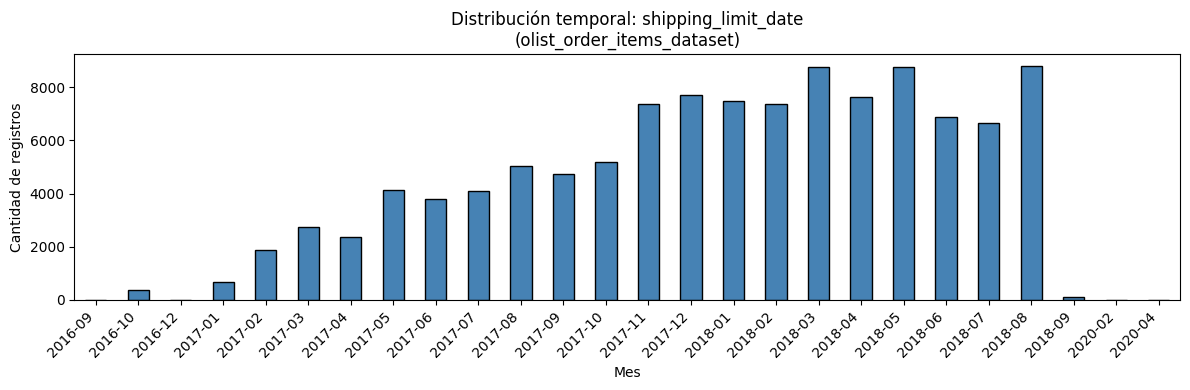

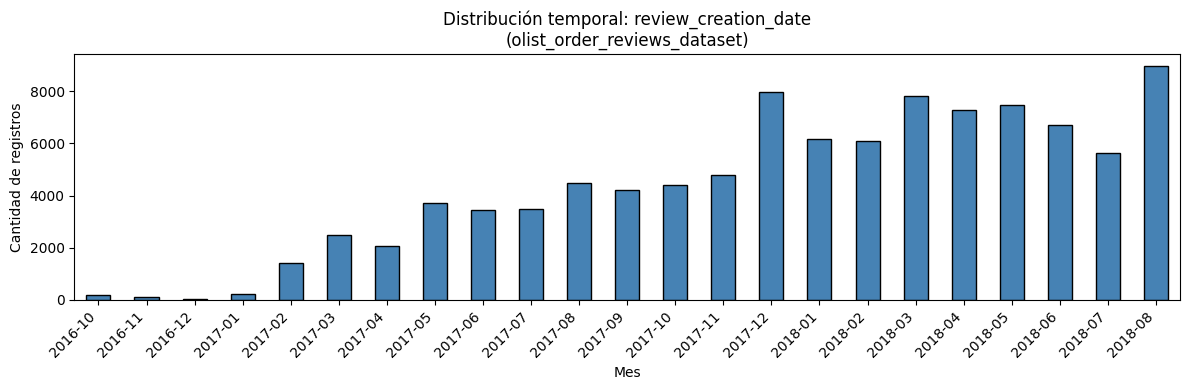

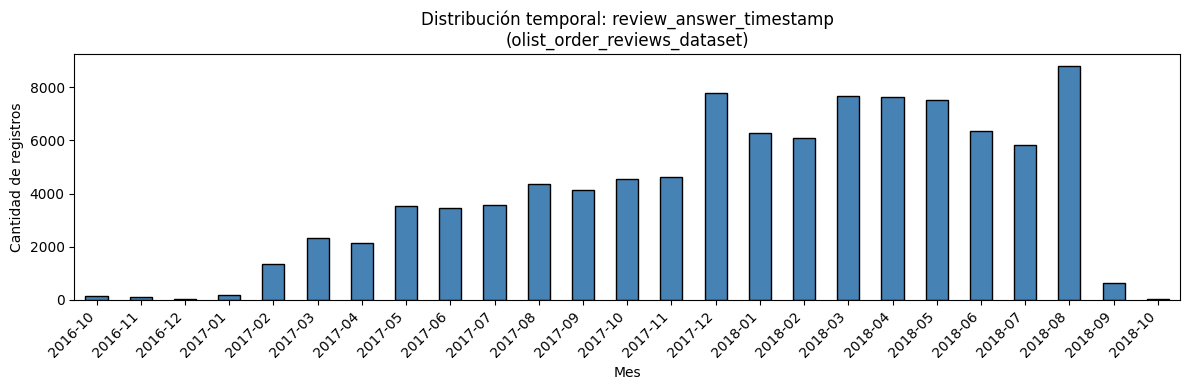

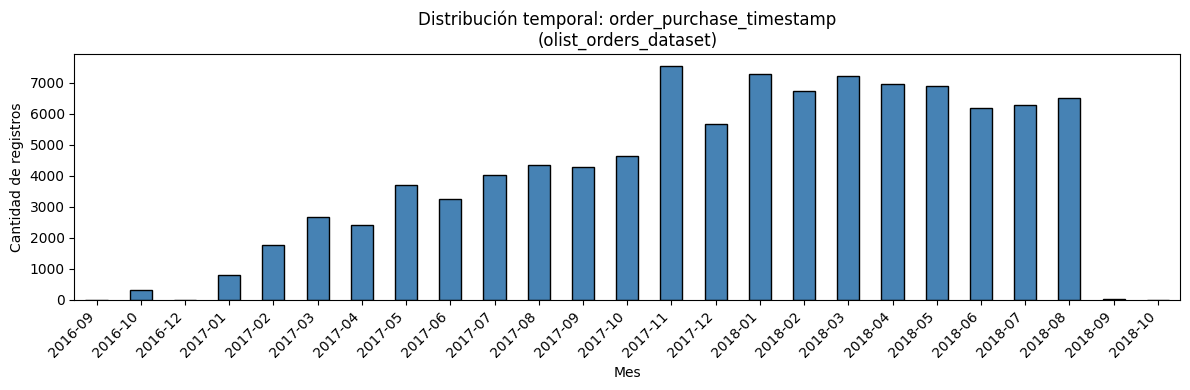

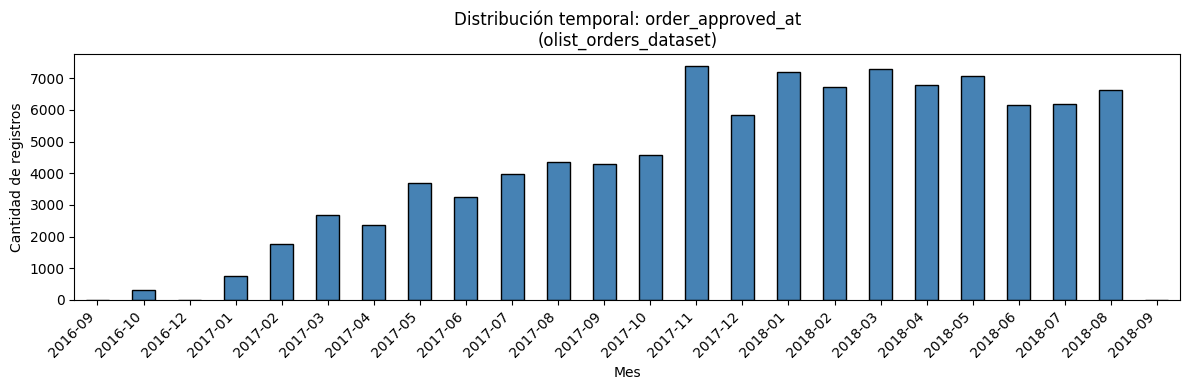

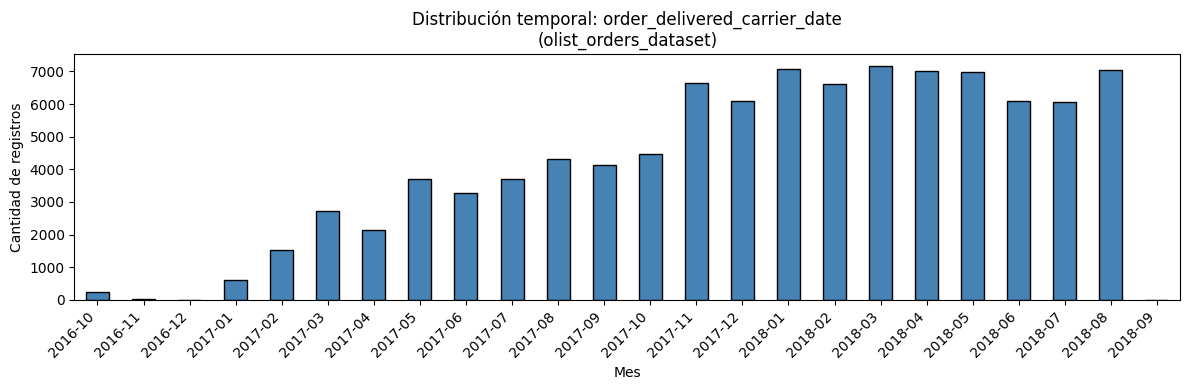

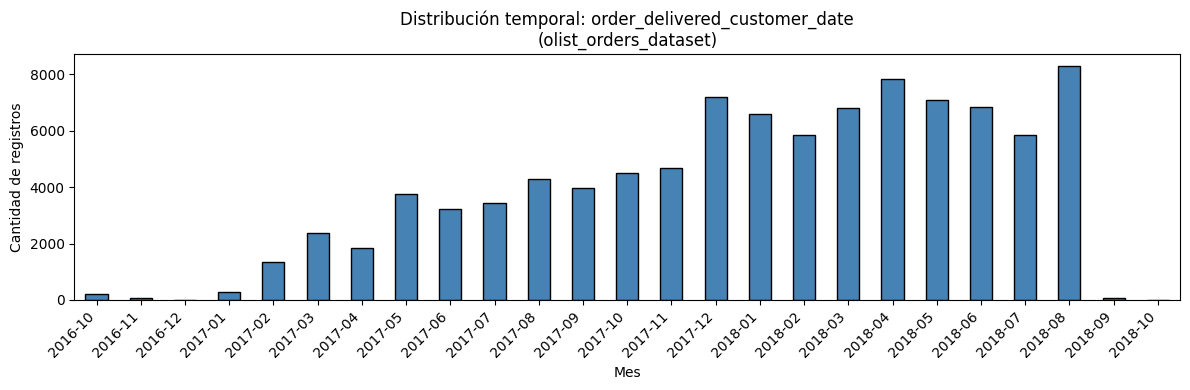

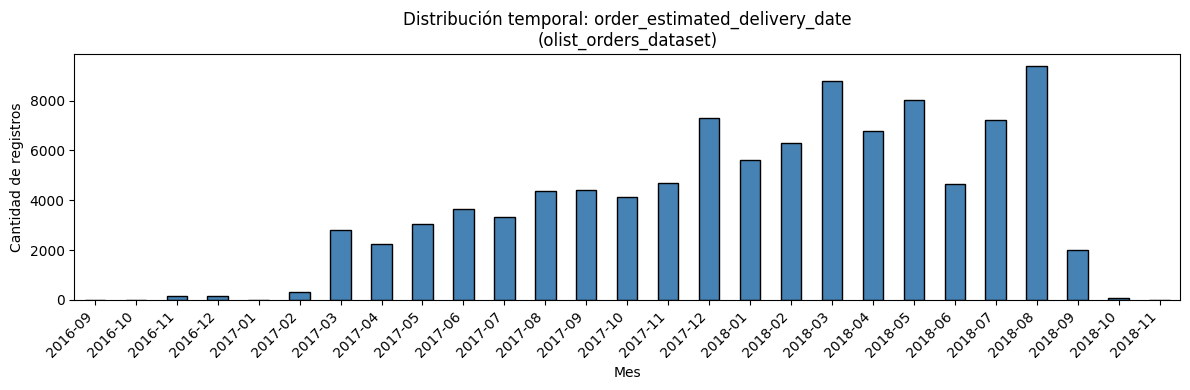

In [34]:
	F_DISTRIBUCION_TEMPORAL(D_DATAFRAMES)

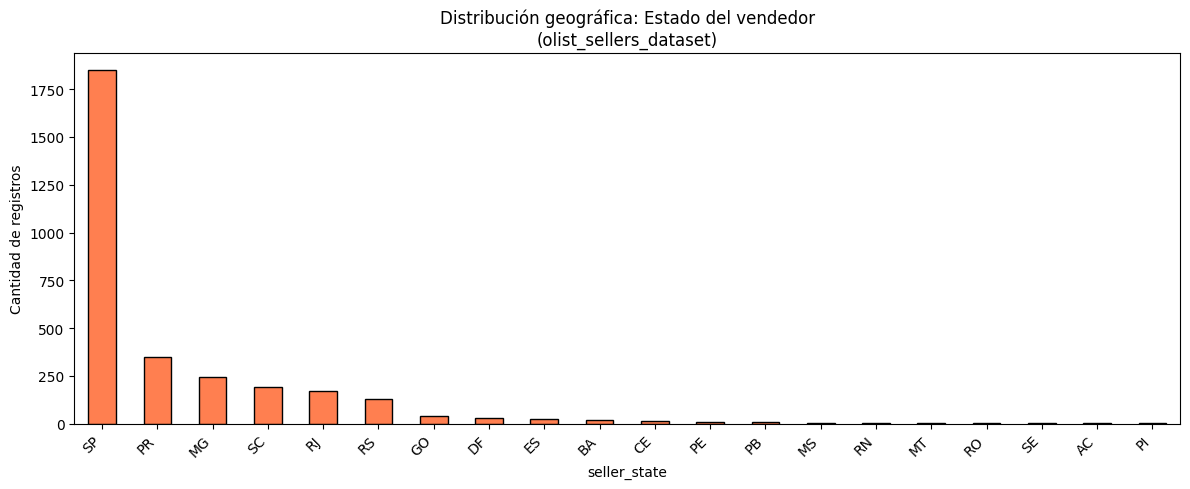

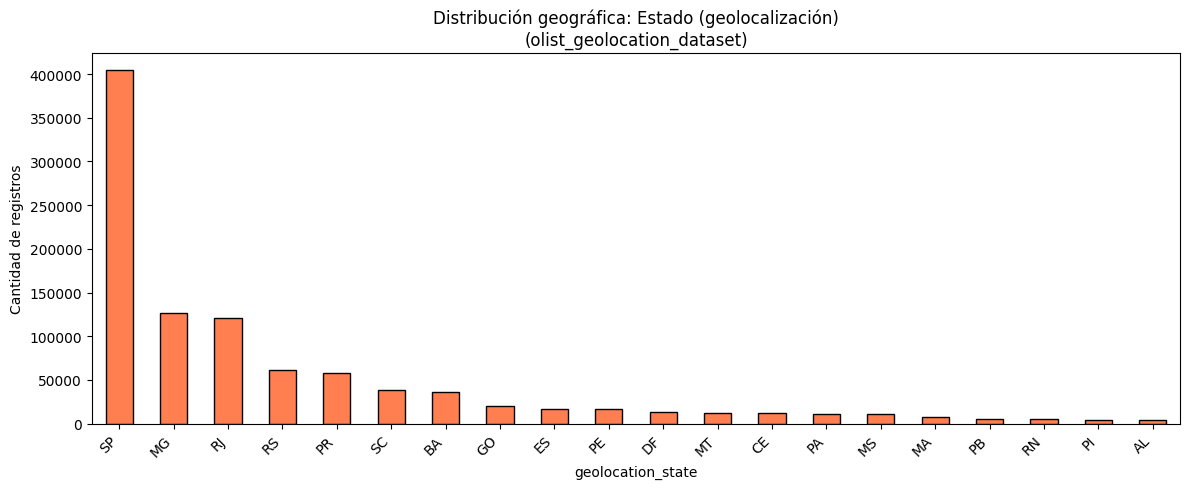

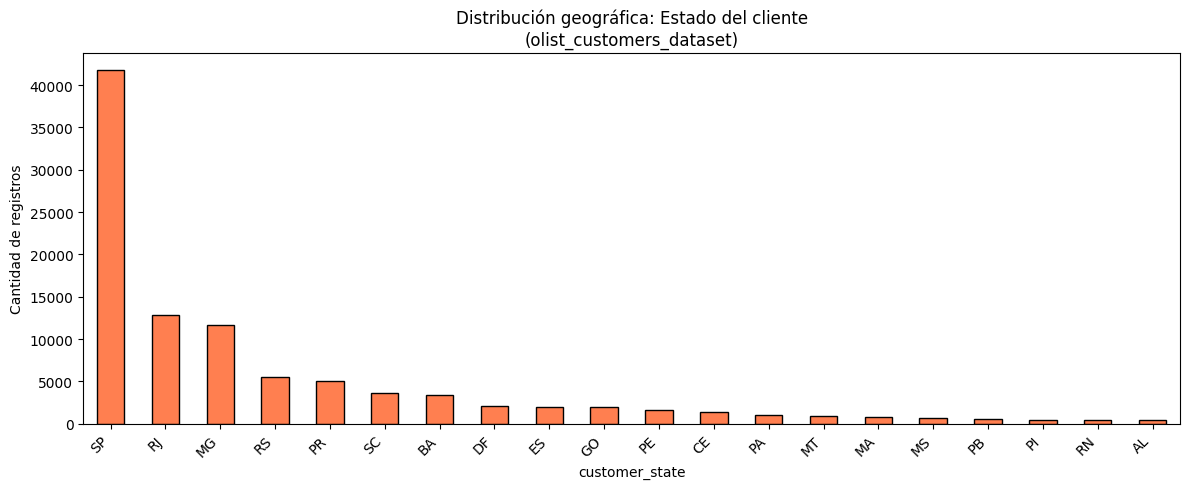

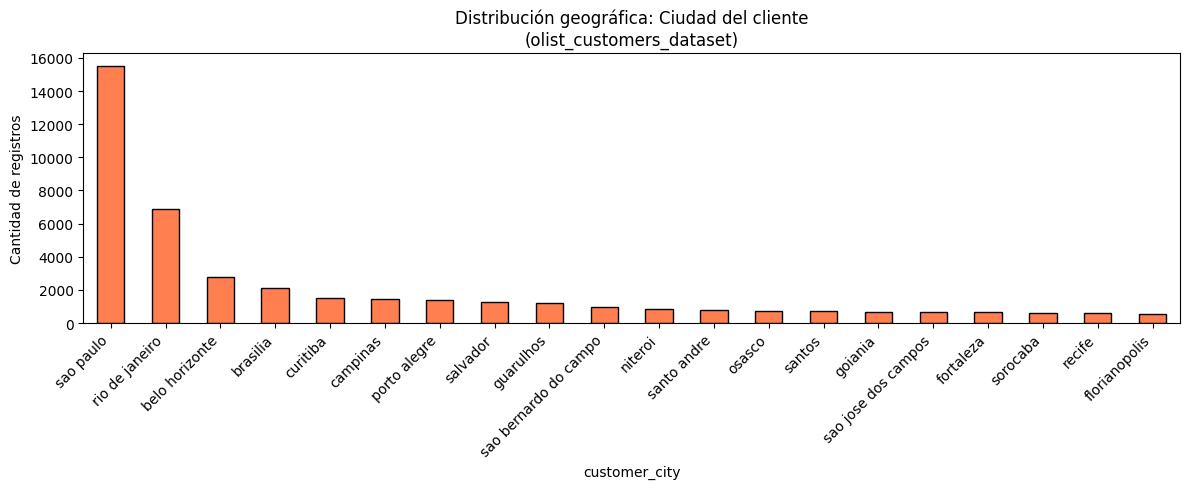

In [35]:
	F_DISTRIBUCION_GEOGRAFICA(D_DATAFRAMES)